In [1]:
# %% Cell 0: Profiling (optional) and Imports
# %load_ext line_profiler # If you want to use %lprun for specific functions
# %load_ext memory_profiler # If you want to use %memit

# Use %%prun at the top of a cell you want to profile with cProfile
# Example:
# %%prun -s cumulative -q -l 15 -T profile_results.txt 
# (This would profile the entire cell's execution)

import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import logging # Good to have for messages from utils
from typing import Optional

# --- Add Project Root to sys.path ---
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR) 
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added project root to sys.path: {PROJECT_ROOT}")

# --- Import Custom Modules ---
from src.config_loader import MDetectorConfigAccessor # MODIFIED: Import accessor
from src.utils.validation_utils import (
    calculate_metrics_for_experiment_hdf5,    
    generate_roc_pr_data_gt_velocity_variant_hdf5, 
    load_config_from_hdf5 # Useful if you need to inspect a specific run's config
)
from src.visualization.metrics_plots import plot_roc_curve, plot_precision_recall_curve
from src.core.constants import OcclusionResult # For OcclusionResult.OCCLUDING_IMAGE.value

print("Cell 0: Imports and Paths - OK")


Added project root to sys.path: /home/drugge/Unsupervised-Moving-Point-Detection/m_detector_python
Cell 0: Imports and Paths - OK


In [2]:
# %% Cell 1: Configuration and Path Setup

# --- Load Configuration using Accessor ---
config_accessor: Optional[MDetectorConfigAccessor] = None
try:
    config_file_path = os.path.join(PROJECT_ROOT, 'config/m_detector_config.yaml') # Base config for defaults
    config_accessor = MDetectorConfigAccessor(config_file_path)
    print(f"Base configuration loaded successfully using MDetectorConfigAccessor from: {config_file_path}")
except FileNotFoundError:
    print(f"ERROR: Base config file not found at {config_file_path}. Cannot load default paths.")
    config_accessor = None # Ensure it's None if loading fails
except Exception as e:
    print(f"Error loading base config with MDetectorConfigAccessor: {e}. Cannot load default paths.")
    config_accessor = None # Ensure it's None

# --- Define Paths for GT Labels and M-Detector Outputs (HDF5) ---
default_gt_labels_dir = None
# This is the PARENT directory where all your tuning subfolders are located
default_base_tuning_results_dir = None

if config_accessor:
    nuscenes_params = config_accessor.get_nuscenes_params()
    default_gt_labels_dir = nuscenes_params.get('label_path')
    if default_gt_labels_dir and not os.path.isabs(default_gt_labels_dir):
        default_gt_labels_dir = os.path.join(PROJECT_ROOT, default_gt_labels_dir)

    mdet_output_paths = config_accessor.get_mdetector_output_paths()
    # This 'save_path' from the base config is now our main directory for tunings
    default_base_tuning_results_dir = mdet_output_paths.get('save_path')
    if default_base_tuning_results_dir and not os.path.isabs(default_base_tuning_results_dir):
        default_base_tuning_results_dir = os.path.join(PROJECT_ROOT, default_base_tuning_results_dir)

# --- User-defined paths ---
GT_LABELS_BASE_DIR_HDF5 = default_gt_labels_dir if default_gt_labels_dir else "/path/to/your/nuscenes_labels_interpolated" # Fallback
BASE_TUNING_RESULTS_DIR = default_base_tuning_results_dir if default_base_tuning_results_dir else "/path/to/your/m_detector_output_parent_dir" # Fallback

print(f"\nUsing Base Directory for Tuning Results: {BASE_TUNING_RESULTS_DIR}")
print(f"Using GT HDF5 Labels From:               {GT_LABELS_BASE_DIR_HDF5}")

if not os.path.isdir(BASE_TUNING_RESULTS_DIR):
    print(f"ERROR: Base tuning results directory does not exist: {BASE_TUNING_RESULTS_DIR}")
    # Consider raising an error or exiting if this critical path is missing
if not os.path.isdir(GT_LABELS_BASE_DIR_HDF5):
    print(f"WARNING: GT labels directory does not exist: {GT_LABELS_BASE_DIR_HDF5}")

# --- Discover Tuning Subdirectories ---
tuning_experiments_to_evaluate = []
if os.path.isdir(BASE_TUNING_RESULTS_DIR):
    for item_name in sorted(os.listdir(BASE_TUNING_RESULTS_DIR)): # Sort for consistent order
        item_path = os.path.join(BASE_TUNING_RESULTS_DIR, item_name)
        # Check if it's a directory and potentially if it contains expected files
        # e.g., a config_tuned_{item_name}.yaml or mdet_results_scene-*.h5 files
        expected_config_file = os.path.join(item_path, f"config_tuned_{item_name}.yaml")
        if os.path.isdir(item_path) and os.path.exists(expected_config_file):
            tuning_experiments_to_evaluate.append({
                "name": item_name,
                "path": item_path,
                "config_path": expected_config_file
            })
        # Alternative check: if it contains HDF5 result files
        # elif os.path.isdir(item_path) and any(f.startswith("mdet_results_") and f.endswith(".h5") for f in os.listdir(item_path)):
        #     tuning_experiments_to_evaluate.append({
        #         "name": item_name,
        #         "path": item_path,
        #         "config_path": None # Or try to find a generic config
        #     })


if not tuning_experiments_to_evaluate:
    print(f"WARNING: No valid tuning subdirectories found in {BASE_TUNING_RESULTS_DIR}")
else:
    print(f"\nFound {len(tuning_experiments_to_evaluate)} tuning experiments to evaluate:")
    for exp in tuning_experiments_to_evaluate:
        print(f"  - Name: {exp['name']}, Path: {exp['path']}")


# --- Base Evaluation Parameters (can still use defaults from base config) ---
base_eval_params = {
    "mdet_label_field_name": "mdet_label",
    "mdet_dynamic_label_value": OcclusionResult.OCCLUDING_IMAGE.value,
    "coordinate_tolerance_for_verification": 1e-3, # Small value for exact point matching
    "mdet_min_point_range_meters": 1.0, # Default, will be overridden by MDet config if available
    "mdet_max_point_range_meters": 50.0, # Default, will be overridden by MDet config if available
    "evaluate_only_keyframes": False  
}
if config_accessor: # Use base config for these general eval params
    point_filter_params = config_accessor.get_point_pre_filtering_params()
    base_eval_params["mdet_min_point_range_meters"] = point_filter_params.get('min_range_meters', base_eval_params["mdet_min_point_range_meters"])
    base_eval_params["mdet_max_point_range_meters"] = point_filter_params.get('max_range_meters', base_eval_params["mdet_max_point_range_meters"])

print(f"\nBase Evaluation Parameters:")
for key, value in base_eval_params.items():
    print(f"  {key}: {value}")

print("\nCell 1: Configuration - OK")

Base configuration loaded successfully using MDetectorConfigAccessor from: /home/drugge/Unsupervised-Moving-Point-Detection/m_detector_python/config/m_detector_config.yaml

Using Base Directory for Tuning Results: /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/m_detector_tuning_30_05_25
Using GT HDF5 Labels From:               /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/nuscenes_labels_interpolated

Found 116 tuning experiments to evaluate:
  - Name: AdapMCCB_Single_dmax_0p8, Path: /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/m_detector_tuning_30_05_25/AdapMCCB_Single_dmax_0p8
  - Name: AdapMCCB_Single_dmin_0p06, Path: /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/m_detector_tuning_30_05_25/AdapMCCB_Single_dmin_0p06
  - Name: AdapMCCB_Single_dthr_18p0, Path: /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/m_detector_tuning_30_05_25/AdapMCCB_Single_dthr_18p0
  - Name: AdapMCCB_Single_kthr_0p02, Path: /home/drugge/staff-umbrella/TeamHolgerResearch/

In [3]:
import pandas as pd
import multiprocessing # Import for parallelization
from tqdm import tqdm

# --- Top-level worker function for metrics calculation ---
def metrics_worker(args_tuple):
    """
    Worker function to calculate metrics for a single tuning experiment.
    """
    tuning_name, mdet_results_dir, gt_labels_dir, eval_params, project_root_for_worker = args_tuple
    
    # --- Ensure PROJECT_ROOT is available in worker if validation_utils needs it ---
    if project_root_for_worker not in sys.path:
         sys.path.append(project_root_for_worker)

    current_summary = calculate_metrics_for_experiment_hdf5(
        mdet_experiment_dir=mdet_results_dir,
        gt_labels_base_dir=gt_labels_dir,
        eval_params=eval_params
    )
    if current_summary:
        current_summary['tuning_name'] = tuning_name
    return current_summary # Return the summary or None if it failed


all_experiments_summaries_from_pool = []

# --- OPTION 1: Evaluate ALL sweeps ---
eval_params_all_sweeps = base_eval_params.copy()
eval_params_all_sweeps["gt_velocity_threshold"] = 1.0 
# eval_params_all_sweeps["evaluate_only_keyframes"] = False # This is the default

# --- OPTION 2: Evaluate ONLY KEYFRAMES ---
eval_params_keyframe_only = base_eval_params.copy()
eval_params_keyframe_only["gt_velocity_threshold"] = 1.0 
eval_params_keyframe_only["evaluate_only_keyframes"] = True # <<< SET TO TRUE FOR KEYFRAME EVALUATION

# --- Choose which eval_params to use for the current run ---
# For example, to run keyframe-only evaluation:
# current_eval_params_to_use = eval_params_keyframe_only
# Or for all sweeps:
current_eval_params_to_use = eval_params_all_sweeps



if not tuning_experiments_to_evaluate:
    print("No tuning experiments found to evaluate in Cell 2.")
else:
    tasks_for_metrics_pool = []
    for experiment_info in tuning_experiments_to_evaluate:
        tasks_for_metrics_pool.append((
            experiment_info["name"],
            experiment_info["path"],
            GT_LABELS_BASE_DIR_HDF5, # from Cell 1
            current_eval_params_to_use,
            PROJECT_ROOT # Pass project root for path resolution in worker
        ))

    # Determine number of cores for metrics calculation (can be different from M-Det run)
    # Let's use a smaller number by default for notebook stability, or make it configurable.
    num_metrics_workers = min(multiprocessing.cpu_count(), len(tasks_for_metrics_pool), 58) # e.g., cap at 58 or len(tasks)
    print(f"\nCalculating metrics in parallel for {len(tasks_for_metrics_pool)} tunings using {num_metrics_workers} workers...")

    with multiprocessing.Pool(processes=num_metrics_workers) as pool:
        with tqdm(total=len(tasks_for_metrics_pool), desc="Calculating All Tuning Metrics") as pbar:
            for result_summary in pool.imap_unordered(metrics_worker, tasks_for_metrics_pool):
                if result_summary:
                    all_experiments_summaries_from_pool.append(result_summary)
                else:
                    # The worker would have logged the error, or calculate_metrics_for_experiment_hdf5 returned None
                    # We can get the tuning name from the input task if needed for more detailed error tracking here
                    pass 
                pbar.update(1)
    
    # --- Display Comparative Table (same as your existing logic but uses all_experiments_summaries_from_pool) ---
    if all_experiments_summaries_from_pool:
        metrics_to_display = [
            'tuning_name', 'Precision', 'Recall', 'F1',
            'overall_iou_dynamic', 'Accuracy', 'TP', 'FP', 'FN', 'TN',
            'num_scenes_successfully_evaluated', 'num_scenes_total_in_dir'
        ]
        data_for_df = []
        for summary in all_experiments_summaries_from_pool:
            row = {metric: summary.get(metric) for metric in metrics_to_display}
            data_for_df.append(row)

        summary_df = pd.DataFrame(data_for_df)
        if not summary_df.empty:
            summary_df = summary_df.set_index('tuning_name')
            eval_mode_description = " (Keyframes Only)" if current_eval_params_to_use.get("evaluate_only_keyframes") else " (All Sweeps)"
            print(f"\n\n===== Overall Comparative Metrics Summary Across Tunings{eval_mode_description} =====")
            float_cols = ['Precision', 'Recall', 'F1', 'overall_iou_dynamic', 'Accuracy']
            for col in float_cols:
                if col in summary_df.columns:
                    summary_df[col] = summary_df[col].apply(lambda x: f'{x:.4f}' if pd.notnull(x) else 'NaN')
            print(summary_df.to_string(columns=[col for col in metrics_to_display if col != 'tuning_name']))
        else:
            print("No data to display in summary DataFrame after processing.")
    else:
        print("\nNo summaries were collected from any tuning experiment after processing.")

print("\nCell 2: Summary Metrics - OK")


Calculating metrics in parallel for 116 tunings using 56 workers...


  Sweeps (mdet_results_scene-0103.h5 (All Sweeps)): 100%|██████████| 380/380 [00:02<00:00, 131.64sweep/s]

  Sweeps (mdet_results_scene-0103.h5 (All Sweeps)): 100%|██████████| 380/380 [00:03<00:00, 123.31sweep/s]

  Sweeps (mdet_results_scene-0103.h5 (All Sweeps)): 100%|██████████| 380/380 [00:03<00:00, 111.81sweep/s]


  Sweeps (mdet_results_scene-0103.h5 (All Sweeps)): 100%|██████████| 380/380 [00:03<00:00, 107.51sweep/s]

  Sweeps (mdet_results_scene-0103.h5 (All Sweeps)):  65%|██████▌   | 248/380 [00:03<00:02, 63.56sweep/s]

  Sweeps (mdet_results_scene-0103.h5 (All Sweeps)): 100%|██████████| 380/380 [00:03<00:00, 100.08sweep/s]

  Sweeps (mdet_results_scene-0103.h5 (All Sweeps)): 100%|██████████| 380/380 [00:03<00:00, 98.50sweep/s] 

  Scenes (HDF5): 100%|██████████| 1/1 [01:38<00:00, 98.79s/it]

  Scenes (HDF5): 100%|██████████| 1/1 [01:38<00:00, 98.94s/it]██▏  | 274/380 [00:02<00:01, 102.51sweep/s]

  Scenes (HDF5): 100%|██████████| 1/1 [01:38<00:00, 98.86s/it]
  Sweeps (mdet_re



===== Overall Comparative Metrics Summary Across Tunings (All Sweeps) =====
                                              Precision  Recall      F1 overall_iou_dynamic Accuracy     TP     FP      FN       TN  num_scenes_successfully_evaluated  num_scenes_total_in_dir
tuning_name                                                                                                                                                                                    
AdapOcc_dthr3p0_kthr0p005_dmax0p7_dmin0p03       0.6180  0.4957  0.5501              0.3795   0.9882  68807  42525   70001  9337753                                  1                        1
AdapMCCB_dthr25p0_kthr0p015_dmax0p7_dmin0p025    0.6160  0.4825  0.5411              0.3709   0.9881  66968  41747   71840  9338531                                  1                        1
AdapOcc_dthr7p0_kthr0p015_dmax0p7_dmin0p03       0.6225  0.4817  0.5431              0.3728   0.9882  66861  40553   71947  9339725                       

In [4]:
# %% Cell 2 (beginning - ensure this worker is defined before use in the pool)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import multiprocessing
from tqdm import tqdm
import os # For os.path.join if needed inside worker, though paths are passed
import sys # For sys.path manipulation in worker

# --- Top-level worker function for generating plot data points ---
def plot_data_worker(args_tuple):
    """
    Worker function to calculate metrics for a single tuning experiment
    at a specific GT velocity threshold.
    """
    tuning_name, mdet_results_dir, gt_labels_dir, eval_params_for_this_point, project_root_for_worker = args_tuple
    
    # Ensure src modules can be imported if worker runs in a new process context
    if project_root_for_worker not in sys.path:
         sys.path.append(project_root_for_worker)
    
    # Re-importing within the worker can sometimes be safer with multiprocessing
    from src.utils.validation_utils import calculate_metrics_for_experiment_hdf5

    experiment_summary = calculate_metrics_for_experiment_hdf5(
        mdet_experiment_dir=mdet_results_dir,
        gt_labels_base_dir=gt_labels_dir,
        eval_params=eval_params_for_this_point # This contains the specific threshold
    )
    
    threshold_used = eval_params_for_this_point.get("gt_velocity_threshold")
    
    # Return identifiers along with the result
    return tuning_name, threshold_used, experiment_summary

# --- The rest of your Cell 2 ---
# Ensure tuning_experiments_to_evaluate, base_eval_params, GT_LABELS_BASE_DIR_HDF5, PROJECT_ROOT are available from Cell 1

if 'tuning_experiments_to_evaluate' not in locals() or not tuning_experiments_to_evaluate:
    print("ERROR: 'tuning_experiments_to_evaluate' not found or empty. Please run Cell 1 first.")
else:
    gt_velocity_thresholds = np.arange(0.1, 3.1, 0.2) # Or your desired range

    # Determine the evaluation mode from base_eval_params (set in Cell 1)
    # This uses your preference for current_eval_params_to_use['evaluate_only_keyframes']
    # by assuming base_eval_params in Cell 1 was set up using that.
    eval_mode_is_keyframes = base_eval_params.get('evaluate_only_keyframes', False)

    print(f"Preparing tasks for {len(tuning_experiments_to_evaluate)} tuning(s) across {len(gt_velocity_thresholds)} GT Velocity Thresholds.")
    print(f"Evaluation mode for plots: {'Keyframes Only' if eval_mode_is_keyframes else 'All Sweeps'}")

    # --- Create all tasks for the multiprocessing pool ---
    tasks_for_plot_data_pool = []
    for experiment_info in tuning_experiments_to_evaluate:
        tuning_name = experiment_info["name"]
        mdet_experiment_dir = experiment_info["path"]
        for threshold in gt_velocity_thresholds:
            # base_eval_params already contains the 'evaluate_only_keyframes' setting
            eval_params_for_task = base_eval_params.copy()
            eval_params_for_task["gt_velocity_threshold"] = threshold
            
            tasks_for_plot_data_pool.append((
                tuning_name,
                mdet_experiment_dir,
                GT_LABELS_BASE_DIR_HDF5, # From Cell 1
                eval_params_for_task,
                PROJECT_ROOT # From Cell 1, for sys.path in worker
            ))

    # --- Dictionary to store raw results from the pool ---
    # Structure: {tuning_name: {threshold: summary_dict, ...}, ...}
    collected_plot_points_from_pool = {exp_info["name"]: {} for exp_info in tuning_experiments_to_evaluate}
    
    if tasks_for_plot_data_pool:
        num_plot_workers = min(multiprocessing.cpu_count(), len(tasks_for_plot_data_pool), 58) # Adjust cap as needed
        print(f"Calculating plot data in parallel using {num_plot_workers} workers for {len(tasks_for_plot_data_pool)} tasks...")

        with multiprocessing.Pool(processes=num_plot_workers) as pool:
            with tqdm(total=len(tasks_for_plot_data_pool), desc="Generating Plot Data") as pbar:
                for tuning_name_res, threshold_res, summary_res in pool.imap_unordered(plot_data_worker, tasks_for_plot_data_pool):
                    if summary_res and not summary_res.get("error"):
                        if tuning_name_res not in collected_plot_points_from_pool: # Should not happen if initialized
                             collected_plot_points_from_pool[tuning_name_res] = {}
                        collected_plot_points_from_pool[tuning_name_res][threshold_res] = summary_res
                    else:
                        # Log or handle failed calculations for a specific point
                        error_detail = summary_res.get("error", "Unknown error") if summary_res else "Worker returned None"
                        # print(f"  Warning: Failed to get summary for {tuning_name_res} at threshold {threshold_res:.2f}. Error: {error_detail}")
                        # Ensure a placeholder if you expect all thresholds for all tunings
                        if tuning_name_res not in collected_plot_points_from_pool:
                             collected_plot_points_from_pool[tuning_name_res] = {}
                        collected_plot_points_from_pool[tuning_name_res][threshold_res] = None # Mark as failed/missing
                    pbar.update(1)
    else:
        print("No tasks generated for plot data calculation.")

    # --- Restructure data for plotting ---
    all_tunings_plot_data_final = {}
    for tuning_name, threshold_data_map in collected_plot_points_from_pool.items():
        current_tuning_metrics_for_plot = {
            "precisions_vs_thresh": [],
            "recalls_vs_thresh": [],
            "f1_scores_vs_thresh": [],
            "ious_dynamic_vs_thresh": []
        }
        for thresh_val in gt_velocity_thresholds: # Iterate in the defined order for consistent plotting
            summary_at_thresh = threshold_data_map.get(thresh_val) # Get the summary for this specific threshold
            if summary_at_thresh and not summary_at_thresh.get("error"):
                current_tuning_metrics_for_plot["precisions_vs_thresh"].append(summary_at_thresh.get('Precision', float('nan')))
                current_tuning_metrics_for_plot["recalls_vs_thresh"].append(summary_at_thresh.get('Recall', float('nan')))
                current_tuning_metrics_for_plot["f1_scores_vs_thresh"].append(summary_at_thresh.get('F1', float('nan')))
                current_tuning_metrics_for_plot["ious_dynamic_vs_thresh"].append(summary_at_thresh.get('overall_iou_dynamic', float('nan')))
            else:
                current_tuning_metrics_for_plot["precisions_vs_thresh"].append(float('nan'))
                current_tuning_metrics_for_plot["recalls_vs_thresh"].append(float('nan'))
                current_tuning_metrics_for_plot["f1_scores_vs_thresh"].append(float('nan'))
                current_tuning_metrics_for_plot["ious_dynamic_vs_thresh"].append(float('nan'))
        all_tunings_plot_data_final[tuning_name] = current_tuning_metrics_for_plot
    
    print("\nFinished calculating all metrics for plotting.\n")

    


Preparing tasks for 11 tuning(s) across 15 GT Velocity Thresholds.
Evaluation mode for plots: All Sweeps
Calculating plot data in parallel using 56 workers for 165 tasks...


  Sweeps (mdet_results_scene-0916.h5 (All Sweeps)): 100%|██████████| 390/390 [00:08<00:00, 45.76sweep/s]
  Sweeps (mdet_results_scene-0916.h5 (All Sweeps)):  33%|███▎      | 129/390 [00:02<00:04, 56.19sweep/s]
Generating Plot Data: 100%|██████████| 165/165 [22:13<00:00,  8.08s/it]



Finished calculating all metrics for plotting.



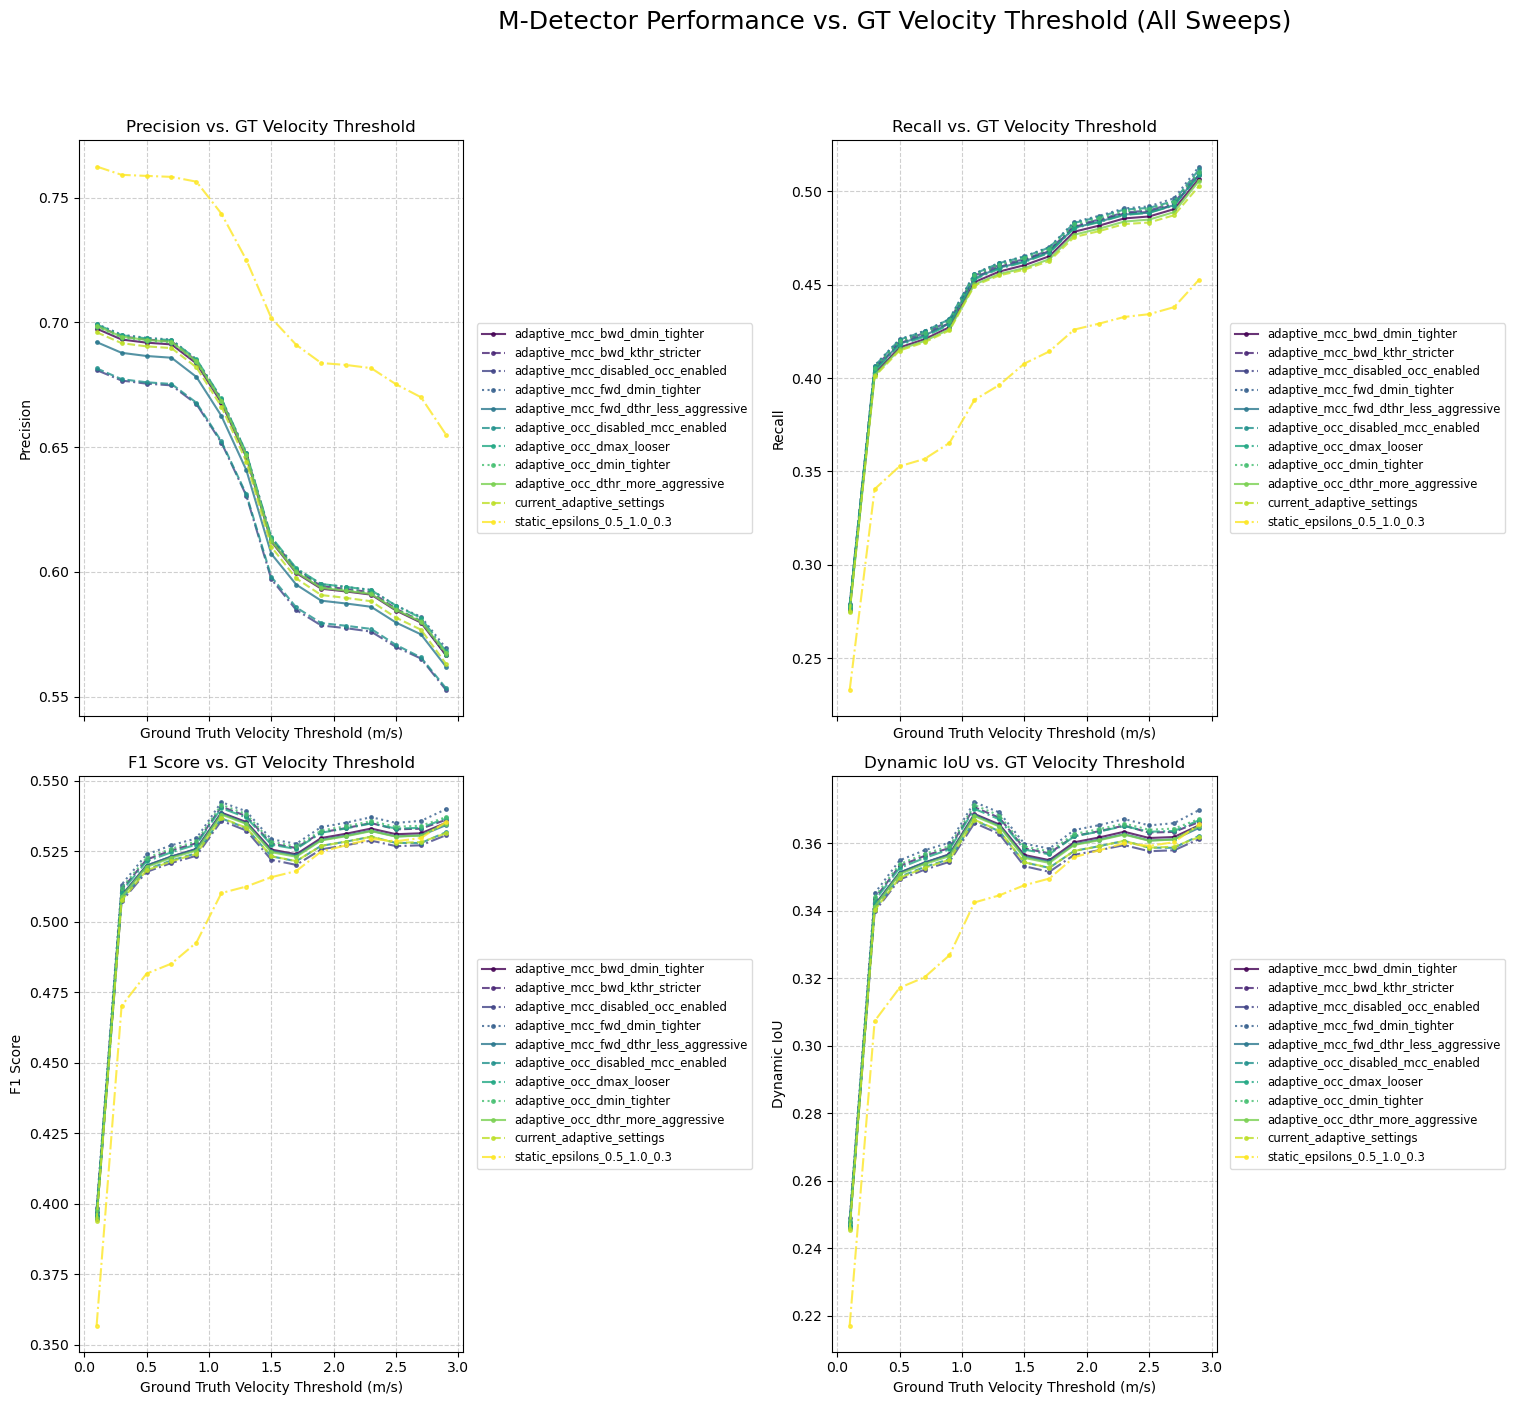


--- Summary of Max F1 Scores from Plots (All Sweeps) ---
                                       Max F1  GT Vel Thresh @ Max F1  Precision @ Max F1  Recall @ Max F1
Tuning                                                                                                    
adaptive_mcc_bwd_dmin_tighter          0.5387                  1.1000              0.6678           0.4514
adaptive_mcc_bwd_kthr_stricter         0.5408                  1.1000              0.6690           0.4538
adaptive_mcc_disabled_occ_enabled      0.5358                  1.1000              0.6519           0.4548
adaptive_mcc_fwd_dmin_tighter          0.5424                  1.1000              0.6694           0.4559
adaptive_mcc_fwd_dthr_less_aggressive  0.5384                  1.1000              0.6626           0.4534
adaptive_occ_disabled_mcc_enabled      0.5366                  1.1000              0.6523           0.4558
adaptive_occ_dmax_looser               0.5403                  1.1000              0.6

In [5]:
# --- Plotting (using all_tunings_plot_data_final) ---
if not all_tunings_plot_data_final:
    print("No data collected for plotting.")
else:
    num_tunings = len(all_tunings_plot_data_final)
    if num_tunings == 0 :
        print("No tuning data to plot.")
    else:
        if num_tunings <= 10: colors = plt.cm.get_cmap('tab10').colors
        else: colors = plt.cm.get_cmap('viridis')(np.linspace(0, 1, num_tunings))
        linestyles = ['-', '--', '-.', ':'] * (num_tunings // 4 + 1)

        fig, axs = plt.subplots(2, 2, figsize=(18, 14), sharex=True) # Slightly larger figure
        axs = axs.ravel()
        plot_metrics_keys = [
            ("Precision", "precisions_vs_thresh"), ("Recall", "recalls_vs_thresh"),
            ("F1 Score", "f1_scores_vs_thresh"), ("Dynamic IoU", "ious_dynamic_vs_thresh")
        ]

        for i, (metric_label, metric_data_key) in enumerate(plot_metrics_keys):
            ax = axs[i]
            for j, (tuning_name, metrics_data) in enumerate(all_tunings_plot_data_final.items()):
                metric_values = metrics_data[metric_data_key]
                # Plot only if there's valid data to prevent errors with all-NaN slices
                if not all(np.isnan(m) for m in metric_values):
                    ax.plot(gt_velocity_thresholds, metric_values,
                            label=tuning_name, color=colors[j % len(colors)],
                            linestyle=linestyles[j % len(linestyles)],
                            marker='.', markersize=5, alpha=0.8) # Adjusted marker and alpha
            ax.set_xlabel("Ground Truth Velocity Threshold (m/s)")
            ax.set_ylabel(metric_label)
            ax.set_title(f"{metric_label} vs. GT Velocity Threshold")
            ax.grid(True, linestyle='--', alpha=0.6)
            # Adjust legend position for many items
            if num_tunings > 6: # Example threshold
                ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize='small', framealpha=0.7)
            else:
                ax.legend(loc='best', fontsize='small', framealpha=0.8)


        plot_mode_title_suffix = " (Keyframes Only)" if eval_mode_is_keyframes else " (All Sweeps)"
        fig.suptitle(f"M-Detector Performance vs. GT Velocity Threshold{plot_mode_title_suffix}", fontsize=18, y=1.0) # Adjusted y for suptitle
        plt.tight_layout(rect=[0, 0, 0.85 if num_tunings > 6 else 1, 0.96]) # Adjust right margin if legend is outside
        plt.show()

        # --- Summary Table (similar to your existing one) ---
        summary_for_table = []
        for tuning_name, metrics_data in all_tunings_plot_data_final.items():
            f1_scores_list = np.array(metrics_data['f1_scores_vs_thresh'])
            valid_f1_scores = f1_scores_list[~np.isnan(f1_scores_list)]
            if len(valid_f1_scores) > 0:
                max_f1_idx = np.nanargmax(f1_scores_list) # nanargmax correctly handles NaNs
                max_f1 = f1_scores_list[max_f1_idx]
                thresh_at_max_f1 = gt_velocity_thresholds[max_f1_idx]
                precision_at_max_f1 = metrics_data['precisions_vs_thresh'][max_f1_idx]
                recall_at_max_f1 = metrics_data['recalls_vs_thresh'][max_f1_idx]
                summary_for_table.append({
                    "Tuning": tuning_name, "Max F1": max_f1,
                    "GT Vel Thresh @ Max F1": thresh_at_max_f1,
                    "Precision @ Max F1": precision_at_max_f1,
                    "Recall @ Max F1": recall_at_max_f1
                })
            else:
                summary_for_table.append({
                    "Tuning": tuning_name, "Max F1": np.nan, "GT Vel Thresh @ Max F1": np.nan,
                    "Precision @ Max F1": np.nan, "Recall @ Max F1": np.nan
                })
        if summary_for_table:
            summary_df_plot = pd.DataFrame(summary_for_table).set_index("Tuning")
            print(f"\n--- Summary of Max F1 Scores from Plots{plot_mode_title_suffix} ---")
            print(summary_df_plot.to_string(float_format="%.4f"))

print("\nCell 2: Plotting vs. GT Velocity Threshold - OK")